# Neural Network Classification with TensorFlow

A [classification problem](https://en.wikipedia.org/wiki/Statistical_classification) involves predicting whether something is one thing or another.

For example, you might want to:
* Predict whether or not someone has heart disease based on their health parameters. This is called **binary classification** since there are only two options.
* Decide whether a photo of is of food, a person or a dog. This is called **multi-class classification** since there are more than two options.
* Predict what categories should be assigned to a Wikipedia article. This is called **multi-label classification** since a single article could have more than one category assigned.


## What we're going to cover

Specifically, we're going to go through doing the following with TensorFlow:
- Architecture of a classification model
- Input shapes and output shapes
  - `X`: features/data (inputs)
  - `y`: labels (outputs)
    - "What class do the inputs belong to?"
- Creating custom data to view and fit
- Steps in modelling for binary and mutliclass classification
  - Creating a model
  - Compiling a model
    - Defining a loss function
    - Setting up an optimizer
      - Finding the best learning rate
    - Creating evaluation metrics
  - Fitting a model (getting it to find patterns in our data)
  - Improving a model
- The power of non-linearity
- Evaluating classification models
  - Visualizng the model
  - Looking at training curves
  - Compare predictions to ground truth (using our evaluation metrics).

#### Typical architecture of a classification neural network

The architecture of a classification neural network can widely vary depending on the problem you're working on.

However, there are some fundamentals all deep neural networks contain:
* An input layer.
* Some hidden layers.
* An output layer.

Much of the rest is up to the data analyst creating the model.

The following are some standard values you'll often use in your classification neural networks.

| **Hyperparameter** | **Binary Classification** | **Multiclass classification** |
| --- | --- | --- |
| Input layer shape | Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited | Same as binary classification |
| Neurons per hidden layer | Problem specific, generally 10 to 100 | Same as binary classification |
| Output layer shape | 1 (one class or the other) | 1 per class (e.g. 3 for food, person or dog photo) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) | Same as binary classification |
| Output activation | [Sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) | [Softmax](https://en.wikipedia.org/wiki/Softmax_function) |
| Loss function | [Cross entropy](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression) ([`tf.keras.losses.BinaryCrossentropy`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy) in TensorFlow) | Cross entropy ([`tf.keras.losses.CategoricalCrossentropy`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy) in TensorFlow) |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) | Same as binary classification |

Table 1: Typical architecture of a classification network. Source: Adapted from page 295 of [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow Book by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)

#### Creating data to view and fit

We could start by importing a classification dataset but let's practice making some of our own classification data.

Since classification is predicting whether something is one thing or another, let's make some data to reflect that.

To do so, we'll use Scikit-Learn's [`make_circles()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html#sklearn.datasets.make_circles) function.

In [1]:
# Importing Necessary Libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import warnings
warnings.filterwarnings('ignore')

2026-01-07 12:32:31.507496: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-07 12:32:32.724256: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-07 12:32:36.247840: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/export/tf2onnx_li

In [2]:
# Dataset from Scikit=Learn:

from sklearn.datasets import make_circles

X, y= make_circles(n_samples= 1000,
                  noise= 0.03,
                  random_state= 42)

In [3]:
X.shape, y.shape

((1000, 2), (1000,))

In [4]:
X[:10], y[:10]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343],
        [-0.47964637,  0.67643477],
        [-0.01364836,  0.80334872],
        [ 0.77151327,  0.14775959],
        [-0.16932234, -0.79345575],
        [-0.1214858 ,  1.02150905]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

In [5]:
# Creating Dataframe from Data:

circles = pd.DataFrame({'X0': X[:, 0],
                       'X1': X[:, 1],
                       'Label': y})

In [6]:
circles.head()

,X0,X1,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [7]:
# Checking how many Lables are there:
circles['Label'].value_counts()

Label
1    500
0    500
Name: count, dtype: int64

Alright, looks like we're dealing with a **binary classification** problem. It's binary because there are only two labels (0 or 1).

If there were more label options (e.g. 0, 1, 2, 3 or 4), it would be called **multiclass classification**.

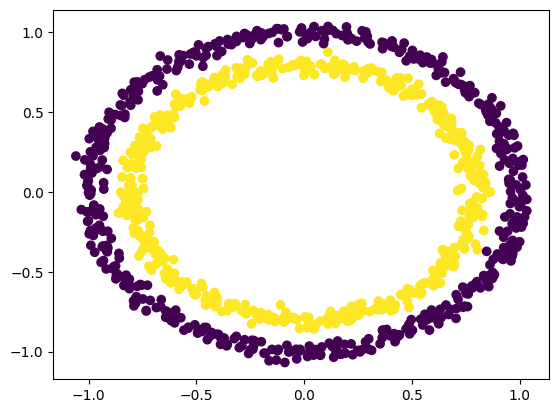

In [8]:
# Visualizing The Data:
plt.scatter(circles['X0'],
           circles['X1'],
           c= circles['Label'])
plt.show()

How about we try and build a model to classify yellow or purple dots? As in, a model which is able to distinguish yellow from purple dots.

> Before pushing forward, you might want to spend 10 minutes playing around with the [TensorFlow Playground](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=2,2&seed=0.93799&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=true&regularizationRate_hide=true&batchSize_hide=true). Try adjusting the different hyperparameters you see and click play to see a neural network train.

#### Input and output shapes

One of the most common issues you'll run into when building neural networks is shape mismatches.

More specifically, the shape of the input data and the shape of the output data.

In our case, we want to input `X` and get our model to predict `y`.

So let's check out the shapes of `X` and `y`.

In [9]:
# Checking Shapes of Features nad Label:

# Features:
print(X.shape)

# Label:
print(y.shape)

(1000, 2)
(1000,)


In [10]:
# Checking a Single Sample of Data and it's Lable:
X[0], y[0]

(array([0.75424625, 0.23148074]), 1)

Alright, so we've got two `X` features which lead to one `y` value.

This means our neural network input shape will has to accept a tensor with at least one dimension being two and output a tensor with at least one value.

>`y` having a shape of (1000,) can seem confusing. However, this is because all `y` values are actually scalars (single values) and therefore don't have a dimension. For now, think of your output shape as being at least the same value as one example of `y` (in our case, the output from our neural network has to be at least one value).

#### Steps in modelling

Now we know what data we have as well as the input and output shapes, let's see how we'd build a neural network to model it.

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. **Creating a model** - piece together the layers of a neural network yourself (using the [functional](https://www.tensorflow.org/guide/keras/functional) or [sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)) or import a previously built model (known as transfer learning).
2. **Compiling a model** - defining how a model's performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).
3. **Fitting a model** - letting the model try to find patterns in the data (how does `X` get to `y`).

In [11]:
# Buiding a Base Model:

tf.random.set_seed(42)

model_1 = Sequential()
model_1.add(Dense(units= 1))
model_1.compile(optimizer= 'sgd',
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics= ['accuracy'])
model_1.fit(X, y, epochs= 10)

Epoch 1/10


I0000 00:00:1767789162.071501     667 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-01-07 12:32:43.008703: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d73f0015b50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-07 12:32:43.008769: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-01-07 12:32:43.081955: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-07 12:32:43.178271: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5373 - loss: 5.7905

I0000 00:00:1767789164.142635     822 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5600 - loss: 6.0139
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5850 - loss: 5.9053
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5480 - loss: 5.6531
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5490 - loss: 5.6514
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5390 - loss: 5.9508
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5450 - loss: 5.6364
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5460 - loss: 5.6273
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5480 - loss: 5.6232
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5490 - loss: 5.6182
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5500 - loss: 5.6176


Looking at the accuracy metric, our model performs poorly (55% accuracy on a binary classification problem is the equivalent of guessing).

Let's try Training for Longer.

In [12]:
model_1.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5490 - loss: 5.6163
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5490 - loss: 5.6156
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5520 - loss: 5.6148
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5520 - loss: 5.6141
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5520 - loss: 5.6135
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5520 - loss: 5.6129
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5520 - loss: 5.6124
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5540 - loss: 5.6119
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5540 - loss: 5.6114
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5530 - loss: 5.6109
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5520 - loss: 5.6105
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

Looks like The Model Accuracy is stuck around 50%, which is very poor.

In [13]:
# Another Model with extra Layer:

tf.random.set_seed(42)

model_2 = Sequential()

model_2.add(Dense(units= 1))
model_2.add(Dense(units= 1))

model_2.compile(optimizer= 'sgd',
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics= ['accuracy'])

model_2.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4920 - loss: 0.9992
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5280 - loss: 0.7006
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5200 - loss: 0.6955
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 0.6946
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4870 - loss: 0.6944
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4810 - loss: 0.6943
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4850 - loss: 0.6942
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4840 - loss: 0.6942
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4730 - loss: 0.6942
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4710 - loss: 0.6942
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4700 - loss: 0.6942
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accur

Accuracy of 46% is even worse than first model, and even worse than guessing.

#### Improving a model

To improve our model, we can alter almost every part of the 3 steps we went through before.

1. **Creating a model** - here you might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
2. **Compiling a model** - you might want to choose a different optimization function (such as the [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) optimizer, which is usually pretty good for many problems) or perhaps change the learning rate of the optimization function.
3. **Fitting a model** - perhaps you could fit a model for more epochs (leave it training for longer).

![various options you can use to improve a neural network model](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/02-improving-a-model-from-model-perspective.png)
*There are many different ways to potentially improve a neural network. Some of the most common include: increasing the number of layers (making the network deeper), increasing the number of hidden units (making the network wider) and changing the learning rate. Because these values are all human-changeable, they're referred to as [hyperparameters](https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning)) and the practice of trying to find the best hyperparameters is referred to as [hyperparameter tuning](https://en.wikipedia.org/wiki/Hyperparameter_optimization).*

In [14]:
# Adding More Neurons, Layers and Changing Optimizer:

tf.random.set_seed(42)

model_3 = Sequential()

model_3.add(Dense(units= 100))
model_3.add(Dense(units= 10))
model_3.add(Dense(units= 1))

model_3.compile(optimizer= 'adam',
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics= ['accuracy'])

model_3.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4820 - loss: 2.3960
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4740 - loss: 0.7320
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4410 - loss: 0.7011
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4940 - loss: 0.6947
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4540 - loss: 0.6941
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4700 - loss: 0.6941
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4660 - loss: 0.6942
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4680 - loss: 0.6943
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4670 - loss: 0.6944
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4650 - loss: 0.6945
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4660 - loss: 0.6946
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy

Still, Around Same Accuracy!

Let's make some visualizations to see what's happening.

Whenever your model is performing strangely or there's something going on with your data you're not quite sure of, remember to **Visualize**. Inspect your data, inspect your model, inpsect your model's predictions.

To visualize our model's predictions we're going to create a function `plot_decision_boundary()` which:
* Takes in a trained model, features (`X`) and labels (`y`).
* Creates a [meshgrid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) of the different `X` values.
* Makes predictions across the meshgrid.
* Plots the predictions as well as a line between the different zones (where each unique class falls).

If you're ever unsure of what a function does, try unraveling it and writing it line by line for yourself to see what it does. Break it into small parts and see what each part outputs.

In [15]:
import numpy as np

def plot_decision_boundary(model, X, y):
  """
  Plots the decision boundary created by a model predicting on X.
  This function has been adapted from two phenomenal resources:
   1. CS231n - https://cs231n.github.io/neural-networks-case-study/
   2. Made with ML basics - https://github.com/GokuMohandas/MadeWithML/blob/main/notebooks/08_Neural_Networks.ipynb
  """
  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X values (we're going to predict on all of these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together: https://numpy.org/devdocs/reference/generated/numpy.c_.html

  # Make predictions using the trained model
  y_pred = model.predict(x_in)

  # Check for multi-class
  if model.output_shape[-1] > 1: # checks the final dimension of the model's output shape, if this is > (greater than) 1, it's multi-class
    print("doing multiclass classification...")
    # We have to reshape our predictions to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classifcation...")
    y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)

  # Plot decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
doing binary classifcation...


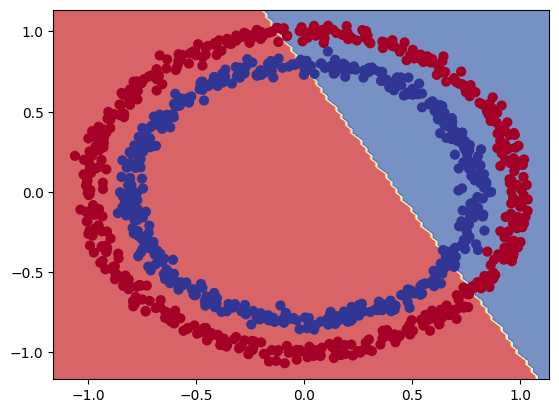

In [16]:
# Let's check how our model is working in finding decision boundry between classes:

plot_decision_boundary(model= model_3, 
                      X= X,
                      y= y)

Looks like our model is trying to draw a straight line through the data.

The main issue is our data isn't separable by a straight line.

In a regression problem, our model might work.

In [17]:
# Trying Same Model on Regression Data:

#Creating Regression Data:
X_reg = tf.range(start= 0, limit= 1000, delta= 5)
y_reg = tf.range(start= 100, limit= 1100, delta= 5)

# Train Test Split:
X_reg_train = X_reg[:150]
X_reg_test = X_reg[150:]
y_reg_train = y_reg[:150]
y_reg_test = y_reg[150:]

In [18]:
print(X_reg_train.shape, X_reg_test.shape, y_reg_train.shape, y_reg_test.shape)

(150,) (50,) (150,) (50,)


In [19]:
# Building Model Same as 'model_3' for Regression:

tf.random.set_seed(42)

model_3_reg = Sequential()

model_3_reg.add(Dense(units= 100))
model_3_reg.add(Dense(units= 10))
model_3_reg.add(Dense(units= 1))

model_3_reg.compile(optimizer= 'adam',
                   loss= 'mae',
                   metrics= ['mae'])

model_3_reg.fit(tf.reshape(X_reg_train, shape= [150,1]),
               y_reg_train,
               epochs= 200)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - loss: 396.3413 - mae: 396.3413
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 266.7491 - mae: 266.7491
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 134.6975 - mae: 134.6975
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 54.5629 - mae: 54.5629
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 89.2164 - mae: 89.2164
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 73.9669 - mae: 73.9669 
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 46.0696 - mae: 46.0696
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 52.5374 - mae: 52.5374
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 42.5105 - mae: 42.5105
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 46.1520 - mae: 46.1520
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 42.1695 - mae: 42.1695
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 43.9170 - mae: 43.9170
Epoch 13/200
5/5 ━

In [20]:
# Making Predictions on Regression Test Data:

y_reg_pred = model_3_reg.predict(y_reg_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 484ms/step


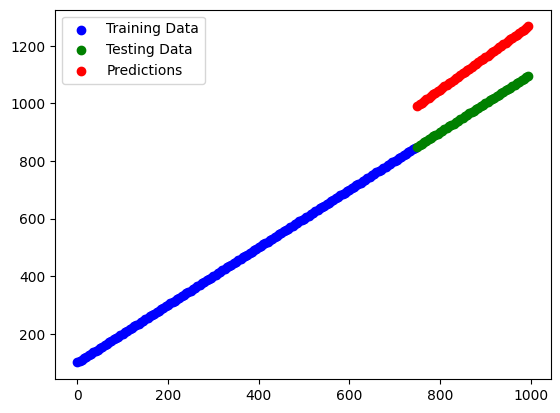

In [21]:
# Plotting Regression Training and Test Data with Predictions:

plt.scatter(X_reg_train, y_reg_train, c= "blue", label= "Training Data")
plt.scatter(X_reg_test, y_reg_test, c= "green", label= "Testing Data")
plt.scatter(X_reg_test, y_reg_pred, c= "red", label= "Predictions")
plt.legend()
plt.show()

Okay, the predictions aren't perfect (if the predictions were perfect, the red would line up with the green), but they look better than complete guessing.

So this means our model must be learning something.

There must be something we're missing out on for our classification problem.

`Introducing Non-Linearity in the Model Using Activation Functions in Hidden Layer:`

In [22]:
tf.random.set_seed(42)

model_4 = Sequential()

model_4.add(Dense(units= 4, activation= 'relu'))
model_4.add(Dense(units= 4, activation= 'relu'))
model_4.add(Dense(units= 1))

model_4.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics = ['accuracy'])

model_4.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4670 - loss: 1.4083
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4300 - loss: 0.7086
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4620 - loss: 0.6976
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4960 - loss: 0.6869
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5830 - loss: 0.6746
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6440 - loss: 0.6566
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7030 - loss: 0.6346
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6970 - loss: 0.6080
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7460 - loss: 0.5752
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7940 - loss: 0.5343
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8310 - loss: 0.4879
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy

In [23]:
# Model Evaluation:
model_4.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5000 - loss: 8.0590


[8.059046745300293, 0.5]

Accuracy is Still Outrageous.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classifcation...


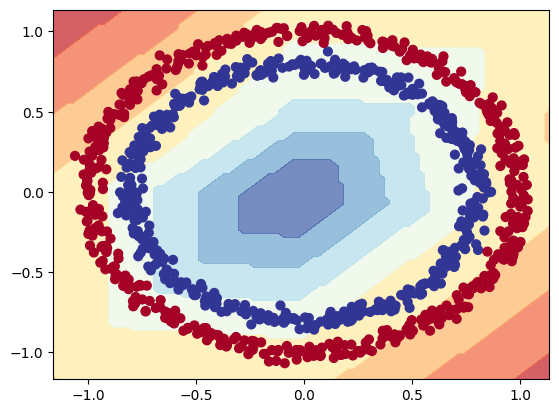

In [24]:
# Plotting Predictions:

plot_decision_boundary(model= model_4,
                      X= X,
                      y= y)

This time we'll change the activation function on our output layer too. Remember the architecture of a classification model? For binary classification, the output layer activation is usually the [Sigmoid activation function](https://www.tensorflow.org/api_docs/python/tf/math/sigmoid).

In [25]:
# Changing Activation Function in Output Layer:

tf.random.set_seed(42)

model_5 = Sequential()

model_5.add(Dense(units= 4, activation= 'relu'))
model_5.add(Dense(units= 4, activation= 'relu'))
model_5.add(Dense(units= 1, activation= 'sigmoid'))

model_5.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
                loss= tf.keras.losses.BinaryCrossentropy,
                metrics= ['accuracy'])

model_5.fit(X, y, epochs= 200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5060 - loss: 0.7002
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5260 - loss: 0.6869
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5530 - loss: 0.6773
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5920 - loss: 0.6639
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6700 - loss: 0.6452
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7660 - loss: 0.6160
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8030 - loss: 0.5765
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8300 - loss: 0.5289
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8330 - loss: 0.4735
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8460 - loss: 0.4241
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8710 - loss: 0.3786
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy

HOORAY!!!! We have almost 100% Accuracy.

In [26]:
# Model Evaluation:
model_5.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9970 - loss: 0.0182


[0.0182498749345541, 0.996999979019165]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classifcation...


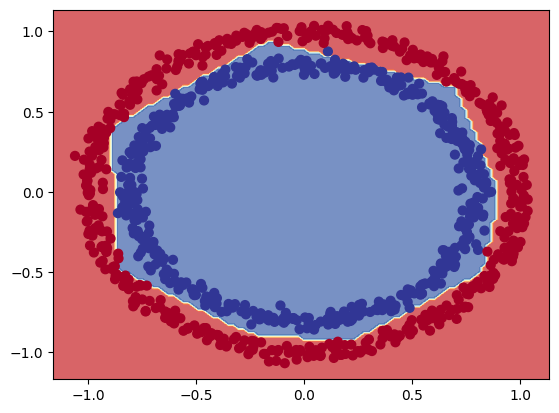

In [27]:
# Plotting Predictions:
plot_decision_boundary(model= model_5,
                      X= X,
                      y= y)

> 🔑 **Note:** The combination of **linear (straight lines) and non-linear (non-straight lines) functions** is one of the key fundamentals of neural networks.

Think of it like this:

If I gave you an unlimited amount of straight lines and non-straight lines, what kind of patterns could you draw?

That's essentially what neural networks do to find patterns in data.

Now you might be thinking, "but I haven't seen a linear function or a non-linear function before..."

Oh but you have.

We've been using them the whole time.

They're what power the layers in the models we just built.

To get some intuition about the activation functions we've just used, let's create them and then try them on some toy data.

In [28]:
# Creating a Toy Tensor:

a = tf.cast(tf.range(-10, 10), tf.float32)

In [29]:
a

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

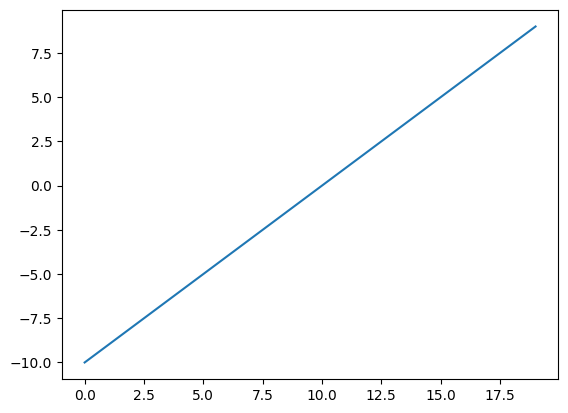

In [30]:
# Visualizing Toy Tensor:

plt.plot(a)
plt.show()

Nice, now let's recreate the [sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function) and see what it does to our data. You can also find a pre-built sigmoid function at [`tf.keras.activations.sigmoid`](https://www.tensorflow.org/api_docs/python/tf/keras/activations/sigmoid).

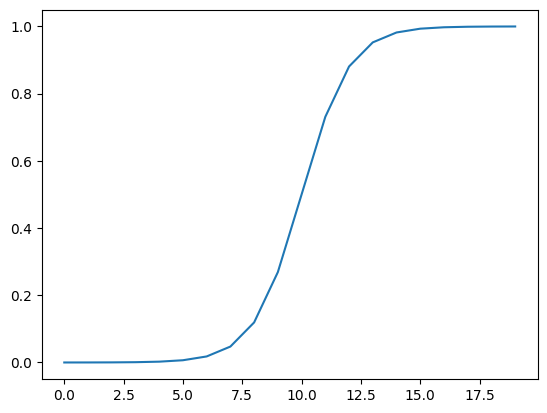

In [31]:
# Plotting Toy Tensor after Applying Sigmoid Function on it:

plt.plot(tf.keras.activations.sigmoid(a))
plt.show()

How about the [ReLU function](https://machinelearningmastery.com/rectified-linear-activation-function-for-deep-learning-neural-networks/#:~:text=The%20rectified%20linear%20activation%20function,otherwise%2C%20it%20will%20output%20zero.) (ReLU turns all negatives to 0 and positive numbers stay the same)?

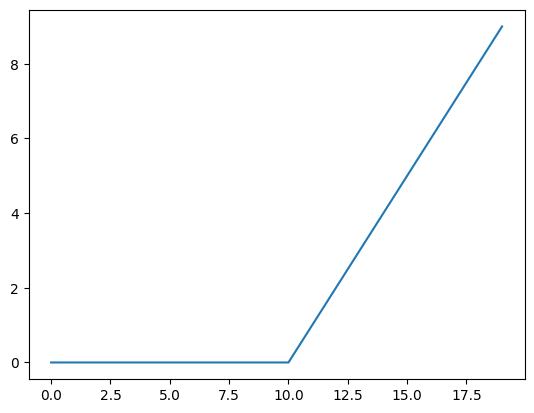

In [32]:
# Plotting Toy Tensor after Applying Relu Function on it:
plt.plot(tf.keras.activations.relu(a))
plt.show()

How about TensorFlow's [linear activation function](https://www.tensorflow.org/api_docs/python/tf/keras/activations/linear)?

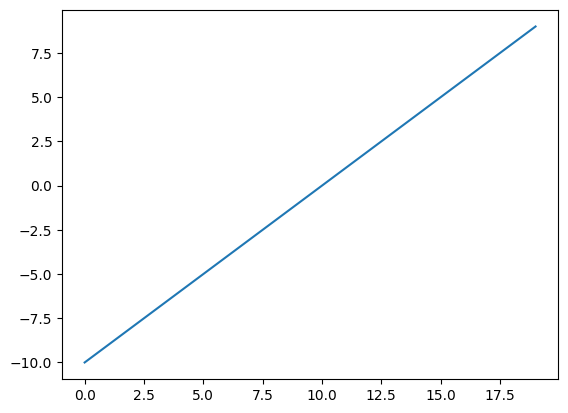

In [33]:
# Plotting Toy Tensor after Applying Linear Function on it:
plt.plot(tf.keras.activations.linear(a))
plt.show()

In [34]:
# Seems like Linear Functions doesn't change anything in Toy Tensor
a == tf.keras.activations.linear(a)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

Okay, so it makes sense now the model doesn't really learn anything when using only linear activation functions, because the linear activation function doesn't change our input data in anyway.

Where as, with our non-linear functions, our data gets manipulated. A neural network uses these kind of transformations at a large scale to figure draw patterns between its inputs and outputs.

For more on activation functions, check out the [machine learning cheatsheet page](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#) on them.

#### Evaluating and improving our classification model


We've been evaluating our model on the same data it was trained on.

A better approach would be to split our data into training, validation (optional) and test sets.

Once we've done that, we'll train our model on the training set (let it find patterns in the data) and then see how well it learned the patterns by using it to predict values on the test set.

In [35]:
# Shape of Our Data:

X.shape, y.shape

((1000, 2), (1000,))

In [36]:
# Train Test Split:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size= 0.2,
                                                   random_state= 42)

In [37]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [42]:
# Creating Neural Network (Same as 'model_5'):

tf.random.set_seed(42)

model_6 = Sequential()

model_6.add(Dense(units= 4, activation= 'relu'))
model_6.add(Dense(units= 4, activation= 'relu'))
model_6.add(Dense(units= 1, activation= 'sigmoid'))

model_6.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.01),
               loss= tf.keras.losses.BinaryCrossentropy,
               metrics= ['accuracy'])

history= model_6.fit(X_train, y_train, epochs= 50)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5125 - loss: 0.6910
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5300 - loss: 0.6850
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5337 - loss: 0.6773
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5825 - loss: 0.6646
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6938 - loss: 0.6451
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7237 - loss: 0.6155
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7775 - loss: 0.5697
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8525 - loss: 0.5011
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9137 - loss: 0.4284
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.3548
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9787 - loss: 0.2894
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9875 - l

In [43]:
# Evaluating The Model:
model_6.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9850 - loss: 0.0395


[0.039461564272642136, 0.9850000143051147]

98.50% Accuracy on Test Data.

Now, when we started to create `model_6` we said it was going to be the same as `model_5` but you might've found that to be a little lie.

That's because we changed a few things:
* **The `learning_rate` (also `lr`) parameter** - We increased the **learning rate** parameter in the [Adam optimizer](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) to `0.01` instead of `0.001` (an increase of 10x).
  * You can think of the learning rate as how quickly a model learns. The higher the learning rate, the faster the model's capacity to learn, however, there's such a thing as a *too high* learning rate, where a model tries to learn too fast and doesn't learn anything.
* **The number of epochs** - We lowered the number of epochs (using the `epochs` parameter) from 200 to 50 but our model still got an incredible result on both the training and test sets.
  * One of the reasons our model performed well in even less epochs (remember a single epoch is the model trying to learn patterns in the data by looking at it once, so 50 epochs means the model gets 50 chances) than before is because we increased the learning rate.

We know our model is performing well based on the evaluation metrics but let's see how it performs visually.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
doing binary classifcation...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
doing binary classifcation...


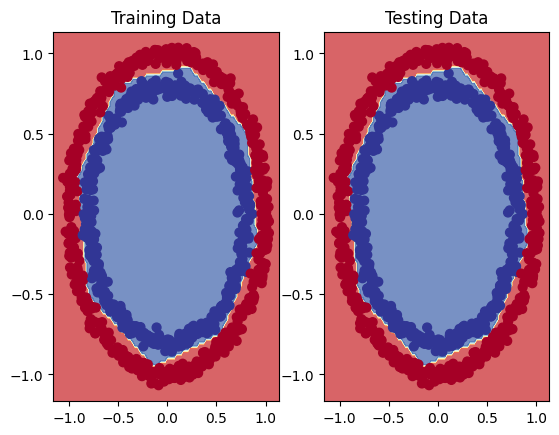

In [44]:
# Plotting Model's Decision Boundry for Training and Test Data:

plt.subplot(1, 2, 1)
plt.title('Training Data')
plot_decision_boundary(model= model_6,
                      X= X,
                      y= y)

plt.subplot(1, 2, 2)
plt.title('Testing Data')
plot_decision_boundary(model= model_6,
                      X= X,
                      y= y)

plt.show()

#### Plot the loss curves

Looking at the plots above, we can see the outputs of our model are very good.

But how did our model go whilst it was learning?

As in, how did the performance change everytime the model had a chance to look at the data (once every epoch)?

To figure this out, we can check the **loss curves** (also referred to as the **learning curves**).

You might've seen we've been using the variable `history` when calling the `fit()` function on a model ([`fit()` returns a `History` object](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit)).

This is where we'll get the information for how our model is performing as it learns.

In [46]:
print(history)

In [47]:
print(type(history))

<class 'keras.src.callbacks.history.History'>


In [48]:
print(type(history.history))

<class 'dict'>


In [49]:
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


In [50]:
pd.DataFrame(history.history).head(10)

,accuracy,loss
0,0.51250,0.690984
1,0.53000,0.684967
2,0.53375,0.677275
3,0.58250,0.664605
4,0.69375,0.645105
5,0.72375,0.615465
6,0.77750,0.569680
7,0.85250,0.501064
8,0.91375,0.428401
9,0.96000,0.354788


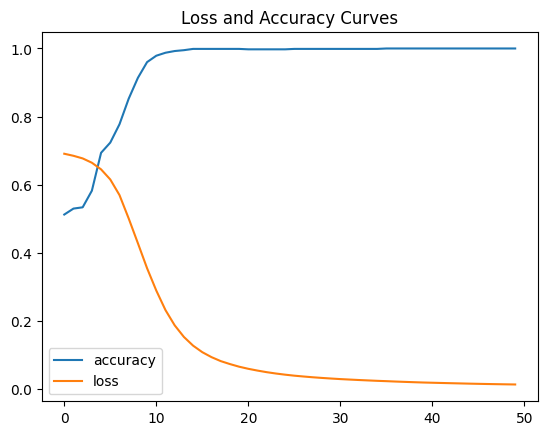

In [51]:
# Plotting Loss and Accuracy Curves:

pd.DataFrame(history.history).plot()
plt.title('Loss and Accuracy Curves')
plt.show()

This is the ideal plot we'd be looking for when dealing with a classification problem, loss going down, accuracy going up.

**For many problems, the loss function going down means the model is improving (the predictions it's making are getting closer to the ground truth labels).**